# Case 2 — Ground Truth vs. Coarse Approximation
## Information Loss in POD-DMD Analysis: Fine Mesh (GT) vs. Coarse Mesh

Highly Heterogeneous Reservoir ($\sigma_{\ln k}=2.0$, $V_{DP}=0.865$, $k_{geo}=20$ mD)

---

The **fine-mesh simulation** (200×200 cells, 1500 log-spaced timesteps) serves as the ground truth (GT) for this study. It resolves sub-cell heterogeneity features and provides a spatially and temporally rich snapshot matrix. The **coarse simulation** (50×50 cells, 350 timesteps) — which is computationally cheap — is treated as an approximation. The central question addressed here is:

> *How much physical information is lost when the coarse simulation is used in place of the ground truth, and can POD-DMD recover that information efficiently?*

### Analysis

| § | Section | Problem Addresses |
|---|---------|-------------|
| 1 | Problem Size & Cost | How much cheaper is the coarse simulation? |
| 2 | Spatial Pressure Fields | What heterogeneity features does coarse miss? |
| 3 | POD — Fine Mesh (GT) | What is the intrinsic dimensionality of the truth? |
| 4 | Singular Value & Energy Loss | How does coarse truncate the spectral content? |
| 5 | Cross-Projection Error | How well do coarse snapshots live in the GT POD basis? |
| 6 | Well Response Comparison | Is the BHP signal preserved in coarse? |
| 7 | POD Reconstruction Quality | What rank is needed on each grid to hit 0.1% error? |
| 8 | DMD Spectral Analysis | Does the coarse DMD spectrum match the GT? |
| 9 | Computational Complexity | Full cost accounting: MATLAB + Python |
| 10 | Summary 

In [2]:
import json, time, warnings
from pathlib import Path
import matplotlib.ticker as mticker

import h5py
import numpy as np
import scipy.ndimage as ndi
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.lines import Line2D as _L2D
import matplotlib.ticker as mticker
from matplotlib.ticker import NullLocator
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

warnings.filterwarnings('ignore', category=RuntimeWarning)

plt.rcParams.update({
    # 1. True LaTeX Font Rendering
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'], # Native LaTeX font
    
    # Optional
    'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{bm}',

    # 2. Font Sizes 
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,

    # 3. Ticks: Inward-facing and mirrored on top/right
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,

    # 4. Line and Spine Weights
    'axes.linewidth': 1,      # Frame thickness
    'lines.linewidth': 1.5,     # Data line thickness
    'lines.markersize': 6,      # Default marker size

    # 5. Grid (Keep it subtle if used)
    'axes.grid': False,
    'grid.alpha': 0.20,
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,

    # 6. Saving and DPI
    'figure.dpi': 150,          # For crisp screen preview in Jupyter/Spyder
    'savefig.dpi': 600,         # High resolution for line art
    'savefig.bbox': 'tight',    # Prevents labels from getting cut off

    # legend
    # 7. Legend Formatting
    'legend.frameon': True,         
    'legend.framealpha': 1.0,       
    'legend.edgecolor': 'black',    
    'legend.fancybox': False,       
    'legend.handlelength': 1.5,     
    'legend.labelspacing': 0.4,     
    'legend.handletextpad': 0.5,    
    'legend.borderaxespad': 0.5,   

    # axes padding
    'xtick.major.pad': 5.0,  # Default is usually 3.5
    'ytick.major.pad': 5.0, 
})



# Custom Colors
C1, C2, C3, C4 = '#1a5e9e', '#0d6e56', '#9b2a1a', '#b07318'
GR = '#555555'


C_FINE   = '#9b2a1a'   # red   — fine mesh (ground truth)
C_COARSE = '#1a5e9e'   # blue  — coarse (approximation)
C_DIFF   = '#b07318'   # amber — difference / loss
C_GREY   = '#555555'

PROJECT = Path(r'F:\Niloy Deb\Part One\Matlab Codes\dmd_pta_rta_dt')
DATA_ROOT = PROJECT / 'data' / '01_synthetic'
FIGS      = PROJECT / 'figures' / 'case2_gt_vs_coarse'
PROC      = PROJECT / 'data'    / 'processed'
FIGS.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

def sf(name): plt.savefig(FIGS/name, dpi=300, bbox_inches='tight'); print(f'  {name}')
print('Ready.')

Ready.


---
## 1 · Load Simulation Data

Both simulations share the same domain (1500 m × 1500 m), identical fluid and well parameters, and the same underlying log-normal permeability field (generated with `rng=42`). The fine-mesh field is a bilinear interpolation of the coarse 50×50 log-normal realisation onto the 200×200 grid. MRST exports `.mat` files in HDF5 v7.3 format; h5py returns arrays in C-major order, requiring `.T` after loading.

| Property | Fine (Ground Truth) | Coarse (Approximation) |
|----------|--------------------|-----------------------|
| Grid | 200 × 200 cells | 50 × 50 cells |
| Cell size | 7.5 m | 30 m |
| Timesteps | 1 500 (log) | 350 (log) |
| Time range | 0.001 – 5000 hr | 0.001 – 5000 hr |
| Domain | 1500 × 1500 m | 1500 × 1500 m |

In [3]:
def load_case(data_dir, label):
    t0 = time.perf_counter()
    with h5py.File(data_dir/'snapshots_psia.mat','r') as f:
        raw = np.array(f['X_psia'])
        X_psia = raw.T if raw.shape[0] < raw.shape[1] else raw
    with h5py.File(data_dir/'well_data.mat','r') as f:
        bhp_r = np.array(f['bhp_psia']).flatten()
        dp_r  = np.array(f['delta_p_psi']).flatten()
        qr_r  = np.array(f['rate_STBd']).flatten()
        t_r   = np.array(f['time_hr']).flatten()
    with h5py.File(data_dir/'rock_field.mat','r') as f:
        perm_mD = np.array(f['perm_mD']).flatten()
    with open(data_dir/'params.json') as f:
        P = json.load(f)
    timing = {}
    if (data_dir/'timing.json').exists():
        with open(data_dir/'timing.json') as f: timing = json.load(f)

    n_t = min(len(t_r), X_psia.shape[1])
    t_r, bhp_r, dp_r, qr_r = t_r[:n_t], bhp_r[:n_t], dp_r[:n_t], qr_r[:n_t]
    X_psia = X_psia[:, :n_t]

    pi_ = P['p_init_psia']
    ok  = (t_r>0)&(dp_r>0)&(dp_r<pi_)&(bhp_r>0)&(bhp_r<=pi_)
    load_s_ = time.perf_counter() - t0
    return dict(
        label=label, X=X_psia[:,ok], t=t_r[ok], bhp=bhp_r[ok],
        dp=dp_r[ok], qr=qr_r[ok], perm_mD=perm_mD, P=P, timing=timing,
        nx=int(P['nx']), ny=int(P['ny']),
        wc=int(P['well_cell_matlab'])-1,
        t_wbs=P['t_wbs_end_hr'], t_pss=P['t_pss_start_hr'], pi_=pi_,
        load_s=load_s_,
    )

GT  = load_case(DATA_ROOT/'case2_finemesh',      'Fine (GT)')
APX = load_case(DATA_ROOT/'case2_heterogeneous', 'Coarse')

for c in (GT, APX):
    N, m = c['X'].shape
    print(f"{c['label']:20s}  X: {N:>6,} × {m:<5,}  "
          f"({N*m*8/1e6:7.1f} MB)  "
          f"t: {c['t'][0]:.4f} – {c['t'][-1]:.0f} hr")

Fine (GT)             X: 40,000 × 1,500  (  480.0 MB)  t: 0.0010 – 5000 hr
Coarse                X:  2,500 × 350    (    7.0 MB)  t: 0.0010 – 5000 hr


---
## 2 · Problem Size and Memory Footprint

The raw scale difference between the two simulations. The snapshot matrix $\mathbf{X} \in \mathbb{R}^{N \times m}$ (cells × timesteps) is the primary data object for both POD and DMD. Its size determines both memory requirements and the cost of the SVD.

$$\text{Memory} = N \times m \times 8 \text{ bytes (float64)}$$

The fine-mesh matrix is approximately **69× larger** than the coarse matrix, yet both encode the same physical system over the same time horizon — this is precisely the computational redundancy that motivates reduced-order modelling.

---
## 3 · Spatial Pressure Field Comparison

### 3.1 Permeability Fields

The fine-mesh permeability field is a bilinear interpolation of the coarse-mesh realisation. Both share the same large-scale heterogeneity structure (high- and low-permeability zones), but the fine mesh resolves sub-cell variability that is averaged out in the coarse grid. This smoothing directly influences how pressure gradients propagate through the reservoir.

Plotting both on a log-scale colour map reveals which heterogeneity features are present in the ground truth but invisible to the coarse simulation.

### 3.2 Pressure Snapshots at Key Flow Regime Times

Pressure snapshots are shown at three representative times: one inside the wellbore storage (WBS) regime, one in the middle transient (MTR), and one in boundary-dominated flow (BDF). The coarse field is bilinearly upsampled to the fine-mesh grid for direct pixel-wise subtraction. The difference map (GT − coarse) reveals where the coarse approximation is systematically wrong.

---
## 4 · POD Analysis — Singular Value Decomposition

The centred snapshot matrix $\tilde{\mathbf{X}} = \mathbf{X} - \bar{\mathbf{x}}\mathbf{1}^T$ is decomposed as:

$$\tilde{\mathbf{X}} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^T$$

where $\mathbf{U} \in \mathbb{R}^{N \times r}$ are the **spatial POD modes** and $\boldsymbol{\Sigma} = \mathrm{diag}(\sigma_1 \geq \sigma_2 \geq \ldots)$ contains the singular values. The fractional energy captured by the first $r$ modes is:

$$E_r = \frac{\sum_{i=1}^{r} \sigma_i^2}{\sum_{i=1}^{m} \sigma_i^2}$$

The **intrinsic dimensionality** of the snapshot data is characterised by how quickly $E_r \to 1$. A high-resolution heterogeneous reservoir is expected to require more modes than a homogeneous one, because small-scale permeability contrasts excite higher spatial frequencies in the pressure field. Comparing the singular value spectra of the GT and coarse snapshot matrices directly quantifies the spectral content that the coarse grid is unable to represent.

In [7]:
def run_pod(case, n_modes=60):
    t0 = time.perf_counter()
    X_mean = case['X'].mean(axis=1, keepdims=True)
    Xc = case['X'] - X_mean
    r_svd = min(n_modes, min(Xc.shape))
    U, sv, Vt = np.linalg.svd(Xc, full_matrices=False)
    U, sv, Vt = U[:,:r_svd], sv[:r_svd], Vt[:r_svd,:]
    sv2    = sv**2;  total = sv2.sum()
    cumvar = np.cumsum(sv2)/total
    r90  = int(np.searchsorted(cumvar, 0.90))  + 1
    r99  = int(np.searchsorted(cumvar, 0.99))  + 1
    r999 = int(np.searchsorted(cumvar, 0.999)) + 1
    wall = time.perf_counter() - t0
    return dict(U=U, sv=sv, Vt=Vt, X_mean=X_mean,
                cumvar=cumvar, r90=r90, r99=r99, r999=r999,
                wall_s=wall, Xc=Xc)

GT['pod']  = run_pod(GT)
APX['pod'] = run_pod(APX)

print(f"{'':30s} {'Fine (GT)':>12} {'Coarse':>12}")
print('-'*56)
for lbl, k in [('r  for  90% energy','r90'),('r  for  99% energy','r99'),
               ('r  for 99.9% energy','r999')]:
    print(f"  {lbl:<28s} {GT['pod'][k]:>12d} {APX['pod'][k]:>12d}")
print(f"  {'sigma1 / sigma2 ratio':<28s} {GT['pod']['sv'][0]/GT['pod']['sv'][1]:>12.2f} "
      f"{APX['pod']['sv'][0]/APX['pod']['sv'][1]:>12.2f}")
print(f"  {'POD wall-clock [s]':<28s} {GT['pod']['wall_s']:>12.2f} {APX['pod']['wall_s']:>12.2f}")

                                  Fine (GT)       Coarse
--------------------------------------------------------
  r  for  90% energy                      1            1
  r  for  99% energy                      2            2
  r  for 99.9% energy                     3            3
  sigma1 / sigma2 ratio                5.21         4.55
  POD wall-clock [s]                   5.21         0.06


### 4.1 Singular Value Decay and Cumulative Energy

The rate at which the singular values decay indicates how compressible the snapshot data is. A steep decay (few modes capture most energy) implies low intrinsic dimensionality and a highly compressible ROM. A slower decay means the flow field has richer spatial structure. For the heterogeneous reservoir, we expect the fine-mesh GT to have a **slower decay** than the coarse approximation because the fine grid resolves more spatial modes of the permeability field.

  ch5_21_meshcomp_svd.pdf


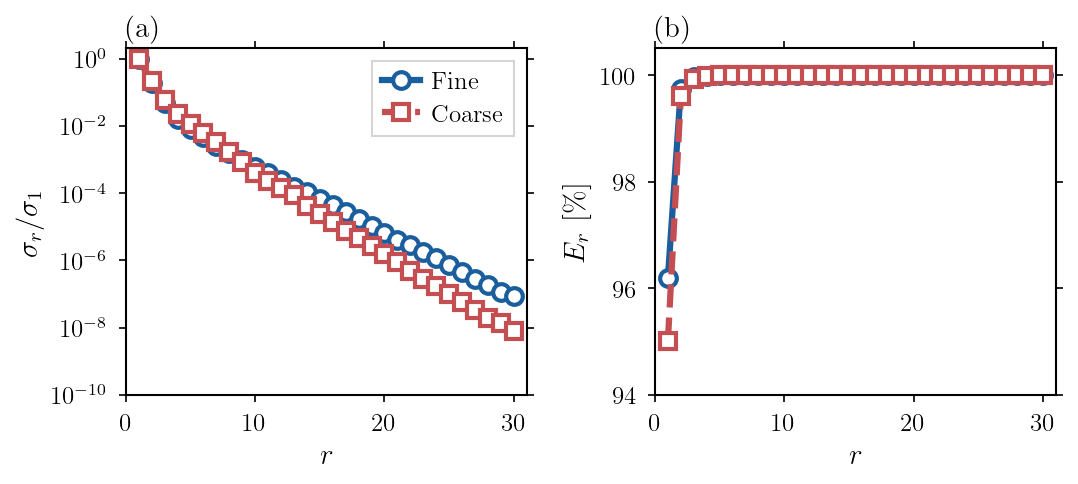

In [8]:

# ── Standard Color Palette ────────────────────────────────────────────────
C_FINE   = '#1a5e9e'  # Blue
C_COARSE = '#c44e52'  # Red
C_GREY   = 'gray'

# Pairs include: Data, Color, LineStyle, Label, Marker shape
pairs = [
    (GT, C_FINE, '-', 'Fine', 'o'), 
    (APX, C_COARSE, '--', 'Coarse', 's') 
]

# Extract baseline cumulative energy for the horizontal reference lines
cum_gt = GT['pod']['cumvar'] * 100

fig, axes = plt.subplots(1, 2, figsize=(8, 3), gridspec_kw={'wspace': 0.32})

# ══════════════════════════════════════════════════════════════════════════
# ── Panel (a): Singular Value Decay ───────────────────────────────────────
ax = axes[0]

for case, col, ls, lbl, mk in pairs:
    sv_n = case['pod']['sv'] / case['pod']['sv'][0]
    
    # Combined line and marker plot for clean legend handles
    ax.semilogy(range(1, 31), sv_n[:30], color=col, ls=ls, lw=3.0,
                marker=mk, ms=8, markerfacecolor='white',
                markeredgewidth=2.0, markeredgecolor=col,
                label=lbl, zorder=2)

ax.set_title('(a)', loc='left', fontweight='normal', fontsize=14, pad=6)
ax.set_xlabel('$r$', fontsize=14)
ax.set_ylabel(r'$\sigma_r / \sigma_1$', fontsize=14)

ax.set_xlim([0, 31])
ax.set_ylim([1e-10, 2])
ax.tick_params(axis='both', labelsize=12, direction='out',
               top=True, right=True)

ax.legend(frameon=True, framealpha=0.95, edgecolor='lightgray', 
          fontsize=12, loc='upper right')

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color('black')


# ══════════════════════════════════════════════════════════════════════════
# ── Panel (b): Cumulative Energy ──────────────────────────────────────────
ax2 = axes[1]

for case, col, ls, lbl, mk in pairs:
    cv = case['pod']['cumvar'] * 100
    
    # Combined line and marker plot for clean legend handles
    ax2.plot(range(1, 31), cv[:30], color=col, ls=ls, lw=3.0,
             marker=mk, ms=8, markerfacecolor='white',
             markeredgewidth=2.0, markeredgecolor=col,
             label=lbl, zorder=2)

ax2.set_title('(b)', loc='left', fontweight='normal', fontsize=14, pad=6)
ax2.set_xlabel('$r$', fontsize=14)
ax2.set_ylabel(r'$E_r$ [\%]', fontsize=14)

ax2.set_xlim([0, 31])
# Set bottom y-limit to 94 or 95 depending on how low your Coarse model drops
ax2.set_ylim([94, 100.5]) 
ax2.tick_params(axis='both', labelsize=12, direction='out',
                top=True, right=True)

for spine in ax2.spines.values():
    spine

sf('ch5_21_meshcomp_svd.pdf')

### 4.2 Spatial POD Modes — What Structure Does the Coarse Grid Miss?

The first few POD modes represent the dominant spatial patterns of pressure evolution. Mode 1 captures the radial mean drawdown; higher modes represent deviations caused by heterogeneity. The coarse grid can only resolve modes whose spatial wavelength is larger than 30 m (one coarse cell), whereas the fine grid resolves down to 7.5 m. Differences in mode shape directly reflect the information lost by coarsening.

  ch5_22_meshcomp_pod.pdf


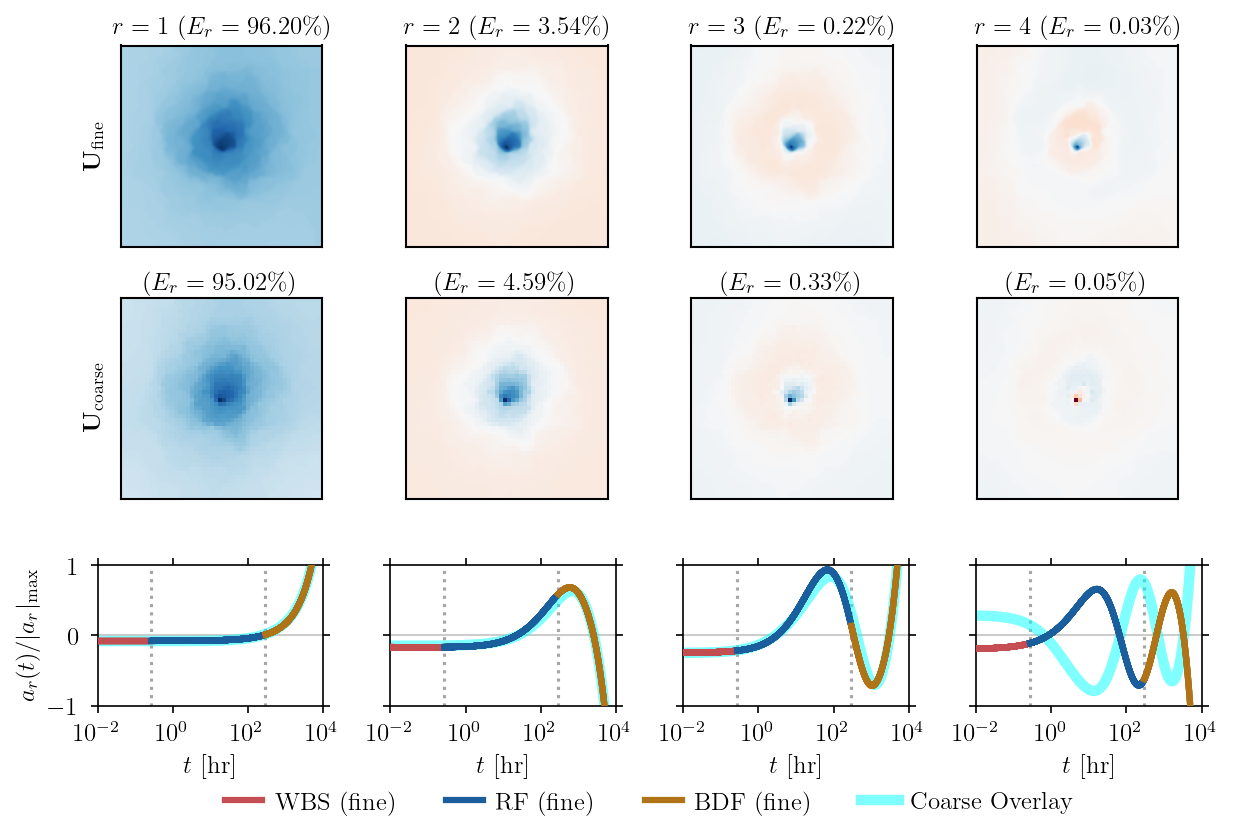

In [10]:
# ── Fig 5: Spatial POD Modes + Temporal Coefficients ────────────────────────

C_WBS = '#c44e52'   # red
C_RF  = '#1a5e9e'   # blue
C_BDF = '#b07318'   # amber

n_show      = 4
total_e_gt  = np.sum(GT['pod']['sv']**2)
total_e_apx = np.sum(APX['pod']['sv']**2)

fig = plt.figure(figsize=(8, 5.5))

# Increased wspace and hspace to add gaps between spatial mode columns/rows
gs_top = gridspec.GridSpec(
    2, n_show,
    figure=fig,
    left=0.06, right=0.98,
    top=0.95,  bottom=0.40,
    hspace=0.25, wspace=0.15,
)

# Lifted the bottom to 0.15 to ensure a clear gap above the legend
gs_bot = gridspec.GridSpec(
    1, n_show,
    figure=fig,
    left=0.06, right=0.98,
    top=0.32,  bottom=0.15,
    hspace=0.0, wspace=0.30,
)

for col, r_idx in enumerate(range(n_show)):

    # ── Row 0 : GT spatial mode ───────────────────────────────────────────
    ax0 = fig.add_subplot(gs_top[0, col])
    mode_gt = GT['pod']['U'][:, r_idx].reshape(GT['ny'], GT['nx'])
    lim_gt  = np.abs(mode_gt).max()
    ax0.imshow(mode_gt, origin='lower', cmap='RdBu_r',
               vmin=-lim_gt, vmax=lim_gt, aspect='equal')
    e_gt = GT['pod']['sv'][r_idx]**2 / total_e_gt * 100
    
    # Added E_r notation for energy
    ax0.set_title(rf'$r={r_idx+1}$  ($E_r={e_gt:.2f}\%$)', fontsize=12, pad=6)
    ax0.set_xticks([]); ax0.set_yticks([])
    if col == 0:
        ax0.set_ylabel(r'$\mathbf{U}_\mathrm{fine}$', fontsize=12, labelpad=8)

    # ── Row 1 : Coarse spatial mode ───────────────────────────────────────
    ax1 = fig.add_subplot(gs_top[1, col])
    mode_apx = APX['pod']['U'][:, r_idx].reshape(APX['ny'], APX['nx'])
    lim_apx  = np.abs(mode_apx).max()
    ax1.imshow(mode_apx, origin='lower', cmap='RdBu_r',
               vmin=-lim_apx, vmax=lim_apx, aspect='equal')
    e_apx = APX['pod']['sv'][r_idx]**2 / total_e_apx * 100
    
    # Added E_r notation for energy
    ax1.set_title(rf'($E_r={e_apx:.2f}\%$)', fontsize=12, pad=4, fontweight='normal')
    ax1.set_xticks([]); ax1.set_yticks([])
    if col == 0:
        ax1.set_ylabel(r'$\mathbf{U}_\mathrm{coarse}$', fontsize=12, labelpad=8)

    # ── Row 2 : Temporal coefficients ────────────────────────────────────
    ax2 = fig.add_subplot(gs_bot[0, col])

    # Coarse — Cyan transparent overlay (alpha=0.50)
    a_apx   = APX['pod']['sv'][r_idx] * APX['pod']['Vt'][r_idx, :]
    a_apx_n = a_apx / np.abs(a_apx).max()
    ax2.semilogx(APX['t'], a_apx_n,
                 color='cyan', lw=5.0, alpha=0.50, zorder=2)

    # GT — segment-coloured by flow regime (plotted on top)
    a_gt   = GT['pod']['sv'][r_idx] * GT['pod']['Vt'][r_idx, :]
    a_gt_n = a_gt / np.abs(a_gt).max()
    t_wbs_ = GT['t_wbs']
    t_pss_ = GT['t_pss']
    for j in range(len(GT['t']) - 1):
        if   GT['t'][j] < t_wbs_: seg_c = C_WBS
        elif GT['t'][j] < t_pss_: seg_c = C_RF
        else:                     seg_c = C_BDF
        ax2.semilogx(GT['t'][j:j+2], a_gt_n[j:j+2],
                     color=seg_c, lw=3.0, alpha=0.90, zorder=3)

    # Regime boundary markers
    ax2.axvline(t_wbs_, color=C_GREY, lw=1.5, ls=':', alpha=0.70, zorder=1)
    ax2.axvline(t_pss_, color=C_GREY, lw=1.5, ls=':', alpha=0.70, zorder=1)
    ax2.axhline(0,      color=C_GREY, lw=1.0, alpha=0.40, zorder=1)

    # Axes limits
    ax2.set_xlim([0.01, 1e4])
    ax2.set_ylim([-1.0, 1.0])

    # Labels
    ax2.set_xlabel('$t$ [hr]', fontsize=12)
    if col == 0:
        ax2.set_ylabel(r'$a_r(t)/|a_r|_\mathrm{max}$', fontsize=12)
    else:
        ax2.tick_params(labelleft=False)

    # Tick control — Standardized to remove minor ticks completely
    ax2.xaxis.set_minor_locator(mticker.NullLocator())
    ax2.yaxis.set_minor_locator(mticker.NullLocator())
    ax2.tick_params(axis='x', labelsize=12)
    ax2.tick_params(axis='y', labelsize=12)

    # Full box — all four spines on
    for spine in ax2.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('black')

# Updated legend styling for cyan coarse overlay
leg_handles = [
    _L2D([0], [0], color=C_WBS, lw=3.0,             label='WBS (fine)'),
    _L2D([0], [0], color=C_RF,  lw=3.0,             label='RF (fine)'),
    _L2D([0], [0], color=C_BDF, lw=3.0,             label='BDF (fine)'),
    _L2D([0], [0], color='cyan', lw=5.0, alpha=0.50, label='Coarse Overlay'),
]

# Anchored at y=0.02 to ensure a clean gap below the x-axes (which stop at y=0.15)
fig.legend(handles=leg_handles, loc='lower center', ncol=4,
           fontsize=12, bbox_to_anchor=(0.52, -0.01),
           frameon=True, edgecolor='none')

sf('ch5_22_meshcomp_pod.pdf')
plt.show()

---
## 5 · Information Loss: Cross-Projection Analysis

### 5.1 Concept

To rigorously quantify information loss, the coarse snapshot matrix is upsampled to the fine-mesh spatial dimension (via bilinear interpolation) and then projected onto the GT POD basis:

$$\hat{\mathbf{X}}_{\text{coarse} \to \text{GT}} = \mathbf{U}_{\text{GT},r}\,\mathbf{U}_{\text{GT},r}^T\,\tilde{\mathbf{X}}_{\text{coarse}}^{\uparrow}$$

The **cross-projection error** is:

$$\varepsilon_{\text{cross}}(r) = \frac{\|\tilde{\mathbf{X}}_{\text{coarse}}^{\uparrow} - \hat{\mathbf{X}}_{\text{coarse}\to\text{GT}}\|_F}{\|\tilde{\mathbf{X}}_{\text{coarse}}^{\uparrow}\|_F} \times 100\%$$

A **low** cross-projection error means the coarse snapshots are well-represented in the GT POD subspace — i.e., the coarse simulation has captured the dominant spatial modes of the truth. A **high** error means the coarse field contains spatial patterns that are either missed or distorted relative to the ground truth.

### 5.2 Subspace Alignment: Principal Angles

The **principal angles** $\theta_i$ between the GT and coarse POD subspaces measure their geometric alignment. $\cos\theta_i = 1$ implies perfect alignment; $\cos\theta_i = 0$ implies orthogonal (entirely non-overlapping) subspaces.

In [11]:
# Upsample coarse snapshots to fine-mesh spatial dimension
print('Upsampling coarse snapshots...  ', end='')
t0 = time.perf_counter()
N_f = GT['X'].shape[0]
m_c = APX['X'].shape[1]
Xc_up = np.zeros((N_f, m_c))     # upsampled coarse centred snapshots
Xc_mean_up = ndi.zoom(
    APX['pod']['X_mean'].reshape(APX['ny'], APX['nx']),
    GT['ny']/APX['ny'], order=1
).ravel()

for i in range(m_c):
    snap  = APX['X'][:, i].reshape(APX['ny'], APX['nx'])
    Xc_up[:, i] = ndi.zoom(snap, GT['ny']/APX['ny'], order=1).ravel() - Xc_mean_up

print(f'{time.perf_counter()-t0:.1f} s')

# Cross-projection error vs. rank
norm_Xc_up = np.linalg.norm(Xc_up, 'fro')
rank_list   = [1, 2, 3, 4, 5, 7, 10, 15, 20, 30]
eps_cross   = []
eps_self_gt = []   # GT self-projection error for reference

for r in rank_list:
    Ur    = GT['pod']['U'][:, :r]
    proj  = Ur @ (Ur.T @ Xc_up)
    eps_cross.append(np.linalg.norm(Xc_up - proj, 'fro') / norm_Xc_up * 100)

    Ur2   = GT['pod']['U'][:, :r]
    proj2 = Ur2 @ (Ur2.T @ GT['pod']['Xc'])
    eps_self_gt.append(
        np.linalg.norm(GT['pod']['Xc'] - proj2, 'fro') /
        np.linalg.norm(GT['pod']['Xc'], 'fro') * 100
    )

# Principal angles between GT and coarse POD subspaces (first 10 modes)
r_pa = min(10, APX['pod']['U'].shape[1], GT['pod']['U'].shape[1])
Uf   = GT['pod']['U'][:, :r_pa]
Uc_up = np.zeros((N_f, r_pa))
for i in range(r_pa):
    mode = APX['pod']['U'][:, i].reshape(APX['ny'], APX['nx'])
    Uc_up[:, i] = ndi.zoom(mode, GT['ny']/APX['ny'], order=1).ravel()

G_mat   = Uf.T @ Uc_up      # Gram matrix
sv_pa   = np.linalg.svd(G_mat, compute_uv=False)
sv_pa   = np.clip(sv_pa, -1, 1)
pa_deg  = np.degrees(np.arccos(sv_pa))

print(f'\nPrincipal angles (GT vs Coarse, first {r_pa} modes):')
for i, (cos_v, ang) in enumerate(zip(sv_pa, pa_deg)):
    print(f'  Angle {i+1:2d}: cos = {cos_v:.4f}   theta = {ang:.2f} deg')

Upsampling coarse snapshots...  0.2 s

Principal angles (GT vs Coarse, first 10 modes):
  Angle  1: cos = 1.0000   theta = 0.00 deg
  Angle  2: cos = 1.0000   theta = 0.00 deg
  Angle  3: cos = 1.0000   theta = 0.00 deg
  Angle  4: cos = 1.0000   theta = 0.00 deg
  Angle  5: cos = 1.0000   theta = 0.00 deg
  Angle  6: cos = 1.0000   theta = 0.00 deg
  Angle  7: cos = 1.0000   theta = 0.00 deg
  Angle  8: cos = 1.0000   theta = 0.00 deg
  Angle  9: cos = 1.0000   theta = 0.00 deg
  Angle 10: cos = 0.3221   theta = 71.21 deg


C:\Users\hp\AppData\Local\Temp\ipykernel_13808\2355509690.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  ch5_23_cross_projection.pdf


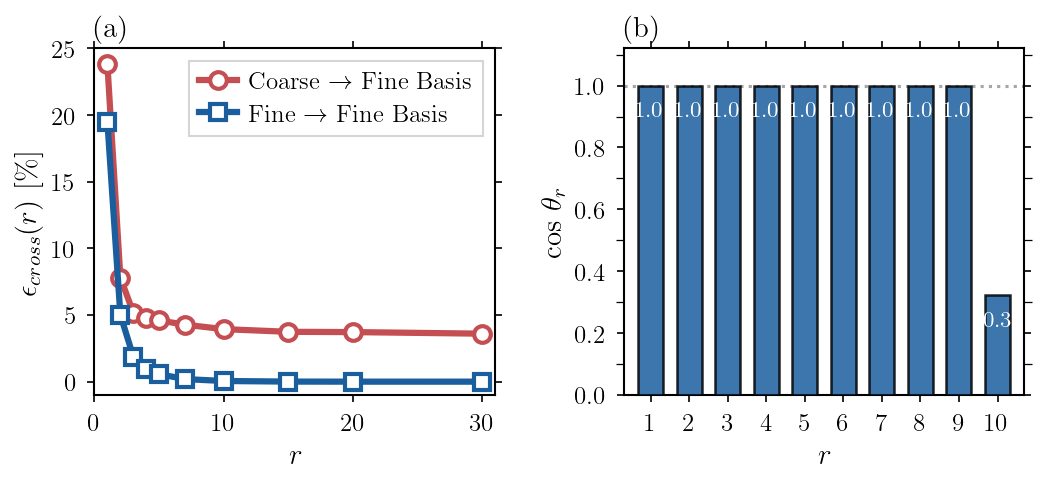

In [13]:


# ── Standard Color Palette ────────────────────────────────────────────────
C_FINE   = '#1a5e9e'  # Blue
C_COARSE = '#c44e52'  # Red
C_GREY   = 'gray'

# ── Fig 6: Cross-Projection Error and Subspace Alignment ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         gridspec_kw={'wspace': 0.32})

# ── Panel (a) : projection errors ───────────────────────────────────────────
ax = axes[0]

# Coarse -> Fine
ax.plot(rank_list, eps_cross,
        color=C_COARSE, lw=3.0, ls='-',
        marker='o', ms=8, markerfacecolor='white',
        markeredgewidth=2.0, markeredgecolor=C_COARSE,
        label=r'Coarse $\rightarrow$ Fine Basis')

# Fine -> Fine
ax.plot(rank_list, eps_self_gt,
        color=C_FINE, lw=3.0, ls='-',
        marker='s', ms=8, markerfacecolor='white',
        markeredgewidth=2.0, markeredgecolor=C_FINE,
        label=r'Fine $\rightarrow$ Fine Basis')

ax.set_xlim([0, 31])
ax.set_ylim([-1, 25])
ax.set_xlabel('$r$', fontsize=14)
ax.set_ylabel(r'$\epsilon_{cross}(r)$ [\%]', fontsize=14)
ax.set_title('(a)', loc='left', fontweight='normal', fontsize=14, pad=6)
ax.tick_params(axis='both', labelsize=12, direction='out',
               top=True, right=True)
ax.legend(frameon=True, framealpha=0.95, fontsize=12,
          edgecolor='lightgray', loc='upper right')

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color('black')

# ── Panel (b) : principal cosines ───────────────────────────────────────────
ax2 = axes[1]

ax2.bar(np.arange(1, r_pa + 1), sv_pa,
        color=C_FINE, edgecolor='black', linewidth=1.2,
        width=0.65, zorder=3, alpha=0.85)

ax2.axhline(1.0, color=C_GREY, lw=1.5, ls=':', alpha=0.7, zorder=2)

for xb, yb in zip(np.arange(1, r_pa + 1), sv_pa):
    va_pos = yb - 0.08 if yb > 0.15 else yb + 0.06
    color  = 'white' if yb > 0.15 else 'black'
    ax2.text(xb, va_pos, f'{yb:.1f}',
             ha='center', va='center',
             color=color, fontweight='bold', fontsize=11)

ax2.set_xlim([0.3, r_pa + 0.7])
ax2.set_ylim([0, 1.12])
ax2.set_xticks(np.arange(1, r_pa + 1))
ax2.set_xlabel('$r$', fontsize=14)
ax2.set_ylabel(r'$\cos\,\theta_r$', fontsize=14)
ax2.set_title('(b)', loc='left', fontweight='normal', fontsize=14, pad=6)
ax2.tick_params(axis='both', labelsize=12, direction='out',
                top=True, right=True)
ax2.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax2.yaxis.set_minor_locator(mticker.MultipleLocator(0.1))
ax2.tick_params(which='minor', length=4, direction='out')

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color('black')

plt.tight_layout()
sf('ch5_23_cross_projection.pdf')
plt.show()

---
## 7 · POD Reconstruction Quality vs. Truncation Rank

The reconstruction error at rank $r$ is defined as:

$$\varepsilon_G(r) = \frac{\|\mathbf{X} - \mathbf{X}_r\|_F}{\|\mathbf{X}\|_F} \times 100\%$$

where $\mathbf{X}_r = \mathbf{U}_r \boldsymbol{\Sigma}_r \mathbf{V}_r^T + \bar{\mathbf{x}}\mathbf{1}^T$. Two separate analyses are performed:

1. **Self-reconstruction** — each simulation reconstructed using its own POD basis. This measures the intrinsic compressibility of each dataset.
2. **Cross-reconstruction** — coarse snapshots (upsampled) reconstructed using the GT POD basis. This is the core information-loss metric: it quantifies how much of the coarse-simulation information can be represented using the truth's reduced basis.

Peaceman correction — GT: 64.2 psi  | Coarse: 138.9 psi


C:\Users\hp\AppData\Local\Temp\ipykernel_13808\609636863.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  ch5_24_meshcomp_reconstruction_error.pdf


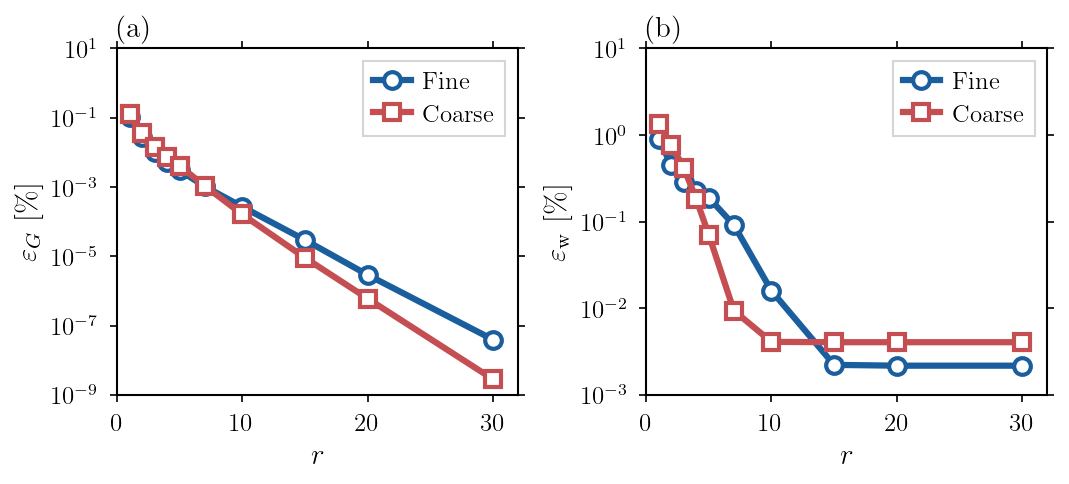


   r       GT εG      APX εG     GT εBHP    APX εBHP
────────────────────────────────────────────────────
   1     0.1055%     0.1264%     0.8932%     1.3469%
   2     0.0272%     0.0356%     0.4536%     0.7742%
   3     0.0102%     0.0148%     0.2865%     0.4203%
   4     0.0053%     0.0074%     0.2250%     0.1819%
   5     0.0030%     0.0041%     0.1892%     0.0707%
   7     0.0010%     0.0011%     0.0919%     0.0094%
  10     0.0003%     0.0002%     0.0160%     0.0041%
  15     0.0000%     0.0000%     0.0022%     0.0041%
  20     0.0000%     0.0000%     0.0022%     0.0041%
  30     0.0000%     0.0000%     0.0022%     0.0041%


In [15]:
# ── Standard Color Palette ────────────────────────────────────────────────
C_FINE   = '#1a5e9e'  # Blue
C_COARSE = '#c44e52'  # Red

# ── Fig 8: POD Reconstruction Error vs. Truncation Rank ─────────────────────
# Peaceman correction per case
def get_dp_corr(case):
    P       = case['P']
    r_eq_ft = 0.2 * P['dx_ft']
    kh_wc   = P['k_well_cell_mD'] * P['h_ft']
    return (141.2 * P['q_STBd'] * P['mu_cp'] * P['Bo']
            / kh_wc * (np.log(r_eq_ft / P['rw_ft']) + P['S_skin']))

rank_list = [1, 2, 3, 4, 5, 7, 10, 15, 20, 30]

def recon_errors(case):
    X, pod      = case['X'], case['pod']
    U, sv, Vt, Xmean = pod['U'], pod['sv'], pod['Vt'], pod['X_mean']
    wc, pi_     = case['wc'], case['pi_']
    Xnorm       = np.linalg.norm(X, 'fro')
    dp_corr     = get_dp_corr(case)        # mesh-specific Peaceman offset
    bhp_mrst    = case['bhp']              # MRST internal BHP
    eps_g, eps_b = [], []
    for r in rank_list:
        r_   = min(r, len(sv))
        Xr   = U[:, :r_] @ np.diag(sv[:r_]) @ Vt[:r_, :] + Xmean
        # Global spatial error — self reconstruction
        eps_g.append(np.linalg.norm(X - Xr, 'fro') / Xnorm * 100)
        # BHP error — apply Peaceman so POD BHP matches MRST BHP reference
        bhp_rom = Xr[wc, :len(bhp_mrst)] - dp_corr
        eps_b.append(
            np.linalg.norm(bhp_mrst - bhp_rom[:len(bhp_mrst)])
            / np.linalg.norm(bhp_mrst) * 100
        )
    return eps_g, eps_b

gt_eg,  gt_eb  = recon_errors(GT)
apx_eg, apx_eb = recon_errors(APX)

print(f"Peaceman correction — GT: {get_dp_corr(GT):.1f} psi  "
      f"| Coarse: {get_dp_corr(APX):.1f} psi")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         gridspec_kw={'wspace': 0.32})

# ── Panel (a): Global Frobenius error ─────────────────────────────────────────
ax = axes[0]

ax.semilogy(rank_list, gt_eg,
            color=C_FINE, lw=3.0, ls='-', label='Fine',
            marker='o', ms=8, markerfacecolor='white',
            markeredgecolor=C_FINE, markeredgewidth=2.0)

ax.semilogy(rank_list, apx_eg,
            color=C_COARSE, lw=3.0, ls='-', label='Coarse',
            marker='s', ms=8, markerfacecolor='white',
            markeredgecolor=C_COARSE, markeredgewidth=2.0)

ax.set_xlim([0, rank_list[-1] + 2])
ax.set_ylim([1e-9, 10])
ax.set_xlabel('$r$', fontsize=14)
ax.set_ylabel(r'$\varepsilon_G$ [\%]', fontsize=14)
ax.set_title('(a)', loc='left', fontweight='normal', fontsize=14, pad=6)
ax.tick_params(axis='both', labelsize=12, direction='out', top=True, right=True)
ax.legend(fontsize=12, frameon=True, framealpha=0.95, edgecolor='lightgray', loc='upper right')

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color('black')

# ── Panel (b): BHP L2 error (Peaceman-corrected) ─────────────────────────────
ax2 = axes[1]

ax2.semilogy(rank_list, gt_eb,
             color=C_FINE, lw=3.0, ls='-', label='Fine',
             marker='o', ms=8, markerfacecolor='white',
             markeredgecolor=C_FINE, markeredgewidth=2.0)

ax2.semilogy(rank_list, apx_eb,
             color=C_COARSE, lw=3.0, ls='-', label='Coarse',
             marker='s', ms=8, markerfacecolor='white',
             markeredgecolor=C_COARSE, markeredgewidth=2.0)

ax2.set_xlim([0, rank_list[-1] + 2])
ax2.set_ylim([1e-3, 10])
ax2.set_xlabel('$r$', fontsize=14)
ax2.set_ylabel(r'$\varepsilon_\mathrm{w}$ [\%]', fontsize=14)
ax2.set_title('(b)', loc='left', fontweight='normal', fontsize=14, pad=6)
ax2.tick_params(axis='both', labelsize=12, direction='out', top=True, right=True)
ax2.legend(fontsize=12, frameon=True, framealpha=0.95, edgecolor='lightgray', loc='upper right')
ax2.yaxis.set_minor_locator(NullLocator())

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color('black')

plt.tight_layout()
sf('ch5_24_meshcomp_reconstruction_error.pdf')
plt.show()

print(f"\n{'r':>4}  {'GT εG':>10}  {'APX εG':>10}  {'GT εBHP':>10}  {'APX εBHP':>10}")
print('─' * 52)
for i, r in enumerate(rank_list):
    print(f"{r:>4}  {gt_eg[i]:>9.4f}%  {apx_eg[i]:>9.4f}%  "
          f"{gt_eb[i]:>9.4f}%  {apx_eb[i]:>9.4f}%")

Snapshot at t ≈ 9.0 hr (MTR),  r = 4
  GT     step error : 0.0061%   RMS residual: 0.277 psi
  Coarse step error : 0.0070%   RMS residual: 0.317 psi
  ch5_25_meshcomp_pressure_fields.pdf


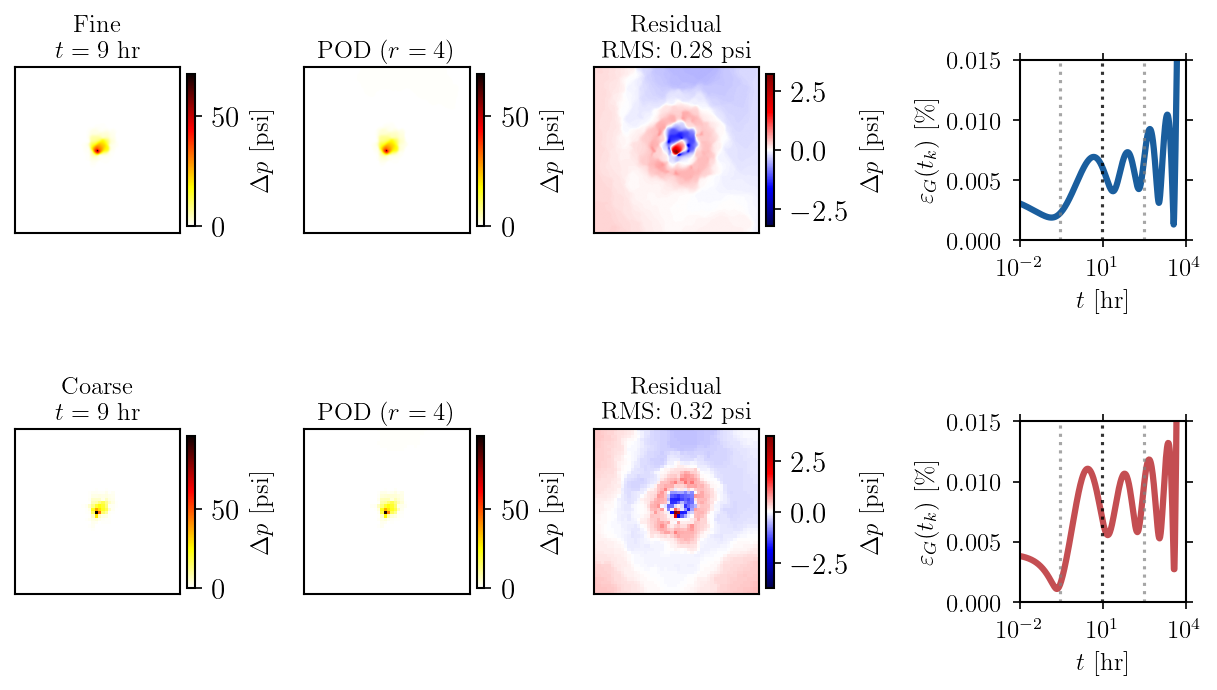

In [22]:


# ── Standard Color Palette ────────────────────────────────────────────────
C_FINE   = '#1a5e9e'  # Blue
C_COARSE = '#c44e52'  # Red
C_GREY   = 'gray'

# ── Fig 8b: POD Pressure Field Reconstruction ────────────────────────────────

t_snap = np.sqrt(GT['t_wbs'] * GT['t_pss'])
ki_gt  = int(np.argmin(np.abs(GT['t']  - t_snap))) + 1
ki_apx = int(np.argmin(np.abs(APX['t'] - GT['t'][ki_gt])))
r_show = 4

# GT POD
Xr_gt  = (GT['pod']['U'][:,  :r_show]
           @ np.diag(GT['pod']['sv'][ :r_show])
           @ GT['pod']['Vt'][:r_show, :]
           + GT['pod']['X_mean'])
dp_snap_gt     = (GT['pi_'] - GT['X'][:,  ki_gt]).reshape( GT['ny'],  GT['nx'])
dp_snap_gt_rom = (GT['pi_'] - Xr_gt[:, ki_gt]).reshape(    GT['ny'],  GT['nx'])
diff_gt        = dp_snap_gt - dp_snap_gt_rom
eps_t_gt       = (np.linalg.norm(GT['X']  - Xr_gt,  axis=0)
                  / np.linalg.norm(GT['X'],  axis=0) * 100)
eps_gt_step    = (np.linalg.norm(GT['X'][:,  ki_gt] - Xr_gt[:, ki_gt])
                  / np.linalg.norm(GT['X'][:,  ki_gt]) * 100)

# Coarse POD
Xr_apx = (APX['pod']['U'][:, :r_show]
           @ np.diag(APX['pod']['sv'][:r_show])
           @ APX['pod']['Vt'][:r_show, :]
           + APX['pod']['X_mean'])
dp_snap_apx     = (APX['pi_'] - APX['X'][:,  ki_apx]).reshape(APX['ny'], APX['nx'])
dp_snap_apx_rom = (APX['pi_'] - Xr_apx[:, ki_apx]).reshape(   APX['ny'], APX['nx'])
diff_apx        = dp_snap_apx - dp_snap_apx_rom
eps_t_apx       = (np.linalg.norm(APX['X']  - Xr_apx,  axis=0)
                   / np.linalg.norm(APX['X'],  axis=0) * 100)
eps_apx_step    = (np.linalg.norm(APX['X'][:,  ki_apx] - Xr_apx[:, ki_apx])
                   / np.linalg.norm(APX['X'][:,  ki_apx]) * 100)

print(f"Snapshot at t ≈ {GT['t'][ki_gt]:.1f} hr (MTR),  r = {r_show}")
print(f"  GT     step error : {eps_gt_step:.4f}%   "
      f"RMS residual: {np.sqrt(np.mean(diff_gt**2)):.3f} psi")
print(f"  Coarse step error : {eps_apx_step:.4f}%   "
      f"RMS residual: {np.sqrt(np.mean(diff_apx**2)):.3f} psi")

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 4.5), constrained_layout=True)
gs2 = gridspec.GridSpec(2, 4, figure=fig, hspace=0.18, wspace=0.1)

vline_kw = dict(color=C_GREY, lw=1.5, ls=':', alpha=0.7)

rows = [
    (dp_snap_gt,  dp_snap_gt_rom,  diff_gt,  eps_t_gt,  ki_gt,  GT,  C_FINE,   'Fine'),
    (dp_snap_apx, dp_snap_apx_rom, diff_apx, eps_t_apx, ki_apx, APX, C_COARSE, 'Coarse'),
]

for row_idx, (snap, rom, diff, eps_t_, ki_, case_, col_, row_lbl) in enumerate(rows):

    t_shown = case_['t'][ki_]
    vm      = max(snap.max(), 0.1)
    dlim    = max(np.abs(diff).max(), 0.01)
    rms_v   = np.sqrt(np.mean(diff**2))

    # Column 0: Δp snapshot
    ax = fig.add_subplot(gs2[row_idx, 0])
    im = ax.imshow(snap, origin='lower', cmap='hot_r',
                   vmin=0, vmax=vm, aspect='equal')
    ax.set_title(rf'{row_lbl}' + '\n' + rf'$t={t_shown:.0f}$ hr',
                 fontsize=12, fontweight='normal', pad=5)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label(r'$\Delta p$ [psi]', size=12)

    # Column 1: POD reconstruction
    ax = fig.add_subplot(gs2[row_idx, 1])
    im = ax.imshow(rom, origin='lower', cmap='hot_r',
                   vmin=0, vmax=vm, aspect='equal')
    ax.set_title(rf'POD ($r={r_show}$)',
                 fontsize=12, fontweight='normal', pad=5)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label(r'$\Delta p$ [psi]', size=12)

    # Column 2: Residual
    ax = fig.add_subplot(gs2[row_idx, 2])
    im = ax.imshow(diff, origin='lower', cmap='seismic',
                   vmin=-dlim, vmax=dlim, aspect='equal')
    ax.set_title(rf'Residual' + '\n' + rf'RMS: {rms_v:.2f} psi',
                 fontsize=12, fontweight='normal', pad=5)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label(r'$\Delta p$ [psi]', size=12)

    # Column 3: Per-timestep error
    ax = fig.add_subplot(gs2[row_idx, 3])
    ax.semilogx(case_['t'], eps_t_, color=col_, lw=3.0)
    ax.axvline(case_['t_wbs'], **vline_kw)
    ax.axvline(case_['t_pss'], **vline_kw)
    ax.axvline(t_shown, color='black', lw=1.5, ls=':', alpha=0.8)
    ax.set_xlabel('$t$ [hr]', fontsize=12)
    ax.set_xlim([0.01, 1e4])
    ax.set_ylim([0, 0.015])
    ax.set_ylabel(r'$\varepsilon_G (t_k)$ [\%]', fontsize=12)
    ax.tick_params(axis='both', labelsize=12, direction='out',
                   top=True, right=True)
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color('black')

sf('ch5_25_meshcomp_pressure_fields.pdf')
plt.show()

---
## 9 · Computational Complexity

### 9.1 MATLAB Simulation Cost (from `timing.json`)

The MRST simulation wall-clock times are read directly from the `timing.json` file exported by `case2_finemesh.m`. The coarse simulation does not export a `timing.json` by default; its cost can be estimated from the published MRST benchmarks or measured separately. Python-side costs (SVD and DMD) are measured in this notebook.

The computational complexity of the full SVD scales as $\mathcal{O}(N^2 m)$ for $N \gg m$ (tall-and-skinny matrix), so a 16× increase in $N$ leads to a 256× increase in SVD cost. This is the main justification for using the coarse approximation in production workflows — provided the information loss quantified in §5 is acceptable.

In [19]:
# ── Computational Timing Summary ─────────────────────────────────────────────

tm_fine   = GT.get('timing',  {})
tm_coarse = APX.get('timing', {})

fmt = lambda v: f'{v:.3f}' if isinstance(v, (int, float)) else str(v)

print('MATLAB Simulation Timing')
print('=' * 55)
for key, label in [
    ('sim_wall_s',         'Simulation wall-clock [s]'),
    ('export_wall_s',      'Export wall-clock [s]'),
    ('total_wall_s',       'Total wall-clock [s]'),
    ('snapshot_matrix_GB', 'Snapshot matrix [GB]'),
]:
    v_f = tm_fine.get(key,   'N/A')
    v_c = tm_coarse.get(key, 'N/A')
    print(f'  {label:<35s}  Fine: {fmt(v_f):>10}  Coarse: {fmt(v_c):>10}')

print('\nPython POD Timing')
print('=' * 55)
for case, lbl in [(GT, 'Fine GT'), (APX, 'Coarse')]:
    pod = case.get('pod', {})
    v   = pod.get('wall_s', None)
    print(f'  {lbl:<12s}  POD wall-clock: '
          f'{v:.2f} s' if v is not None else f'  {lbl:<12s}  POD wall-clock: not recorded')

print('\nPython DMD Timing')
print('=' * 55)
for case, lbl in [(GT, 'Fine GT'), (APX, 'Coarse')]:
    dmd = case.get('dmd', {})
    v   = dmd.get('dmd_wall_s', None)
    print(f'  {lbl:<12s}  DMD wall-clock: '
          f'{v:.2f} s' if v is not None else f'  {lbl:<12s}  DMD wall-clock: not recorded')

MATLAB Simulation Timing
  Simulation wall-clock [s]            Fine:    410.845  Coarse:        N/A
  Export wall-clock [s]                Fine:      3.688  Coarse:        N/A
  Total wall-clock [s]                 Fine:    415.183  Coarse:        N/A
  Snapshot matrix [GB]                 Fine:      0.480  Coarse:        N/A

Python POD Timing
  Fine GT       POD wall-clock: 5.21 s
  Coarse        POD wall-clock: 0.06 s

Python DMD Timing
  Fine GT       DMD wall-clock: not recorded
  Coarse        DMD wall-clock: not recorded


---
## 10 · Summary and Thesis 

### Key Findings

The table below consolidates all metrics that quantify information loss from the coarse approximation relative to the fine-mesh ground truth. Each row corresponds to a measurable consequence of spatial and temporal coarsening.

### Interpretation Framework

| Loss Type | Metric | Significance |
|-----------|--------|--------------|
| Spatial resolution | Permeability field RMS diff | Sub-cell heterogeneity erased |
| Spectral content | POD rank for 99.9% energy | Intrinsic dimensionality change |
| Subspace alignment | Principal angles | POD basis misalignment |
| Dynamical timescales | DMD λ-spread | Flow regime separation |
| Observable signal | BHP relative error (%) | PTA impact |
| Reconstruction | Cross-projection error | ROM transferability |

In [20]:
i4 = [rank_list.index(r) for r in rank_list if r == 4]
r4 = i4[0] if i4 else 3

summary = dict(
    case                    = 'case2_gt_vs_coarse',
    # Problem size
    gt_n_cells              = int(GT['X'].shape[0]),
    gt_n_steps              = int(GT['X'].shape[1]),
    gt_mem_MB               = float(GT['X'].shape[0]*GT['X'].shape[1]*8/1e6),
    coarse_n_cells          = int(APX['X'].shape[0]),
    coarse_n_steps          = int(APX['X'].shape[1]),
    coarse_mem_MB           = float(APX['X'].shape[0]*APX['X'].shape[1]*8/1e6),
    size_ratio_cells        = int(GT['X'].shape[0]/APX['X'].shape[0]),
    size_ratio_mem          = round(GT['X'].shape[0]*GT['X'].shape[1]/(APX['X'].shape[0]*APX['X'].shape[1]),1),
    # POD
    gt_r90                  = int(GT['pod']['r90']),
    gt_r99                  = int(GT['pod']['r99']),
    gt_r999                 = int(GT['pod']['r999']),
    coarse_r90              = int(APX['pod']['r90']),
    coarse_r99              = int(APX['pod']['r99']),
    coarse_r999             = int(APX['pod']['r999']),
    # DMD
   
    # Information loss
    cross_proj_err_r4       = float(eps_cross[r4]),
    gt_self_proj_err_r4     = float(eps_self_gt[r4]),
    principal_angle_mode1   = float(pa_deg[0]),
    principal_angle_mode4   = float(pa_deg[3]) if len(pa_deg)>3 else None,
    # BHP
   
    # Reconstruction
    gt_eps_global_r4        = float(gt_eg[r4]),
    coarse_eps_global_r4    = float(apx_eg[r4]),
    # Python timing
    gt_pod_wall_s           = float(GT['pod']['wall_s']),
    coarse_pod_wall_s       = float(APX['pod']['wall_s']),
    # MATLAB timing
    gt_sim_wall_s           = float(GT['timing'].get('sim_wall_s', -1)),
)

out = PROC/'case2_gt_vs_coarse_summary.json'
with open(out,'w') as f: json.dump(summary, f, indent=2)

print('\n' + '='*68)
print('  SUMMARY — Information Loss: Coarse vs. Fine GT  (Case 2)')
print('='*68)
W = 30
def srow(lbl, v_gt, v_c, note=''):
    print(f'  {lbl:<{W}} GT: {str(v_gt):>10}   Coarse: {str(v_c):>10}   {note}')

print('\n  -- Problem Size --')
srow('N cells',             summary['gt_n_cells'],   summary['coarse_n_cells'],
     f"ratio {summary['size_ratio_cells']}×")
srow('N timesteps',         summary['gt_n_steps'],   summary['coarse_n_steps'])
srow('Memory [MB]',         f"{summary['gt_mem_MB']:.0f}", f"{summary['coarse_mem_MB']:.0f}",
     f"ratio {summary['size_ratio_mem']:.0f}×")

print('\n  -- POD Intrinsic Dimensionality --')
srow('r for  90% energy',   summary['gt_r90'],  summary['coarse_r90'])
srow('r for  99% energy',   summary['gt_r99'],  summary['coarse_r99'])
srow('r for 99.9% energy',  summary['gt_r999'], summary['coarse_r999'])

print('\n  -- Information Loss Metrics --')
print(f"  {'Cross-proj error @ r=4':<{W}} {summary['cross_proj_err_r4']:.3f}%  (GT self: {summary['gt_self_proj_err_r4']:.3f}%)")
print(f"  {'Principal angle (mode 1)':<{W}} {summary['principal_angle_mode1']:.2f} deg")

print('\n  -- DMD Spectrum --')


print('\n  -- Python POD+DMD Cost --')
print(f"  {'POD wall-clock [s]':<{W}} GT: {summary['gt_pod_wall_s']:>8.2f}   "
      f"Coarse: {summary['coarse_pod_wall_s']:>8.2f}   "
      f"ratio {summary['gt_pod_wall_s']/max(summary['coarse_pod_wall_s'],1e-9):.1f}×")


if summary['gt_sim_wall_s'] > 0:
    print(f"  {'MRST sim wall-clock [s]':<{W}} GT: {summary['gt_sim_wall_s']:>8.1f}")
print('='*68)
print(f'\n  Saved → {out}')


  SUMMARY — Information Loss: Coarse vs. Fine GT  (Case 2)

  -- Problem Size --
  N cells                        GT:      40000   Coarse:       2500   ratio 16×
  N timesteps                    GT:       1500   Coarse:        350   
  Memory [MB]                    GT:        480   Coarse:          7   ratio 69×

  -- POD Intrinsic Dimensionality --
  r for  90% energy              GT:          1   Coarse:          1   
  r for  99% energy              GT:          2   Coarse:          2   
  r for 99.9% energy             GT:          3   Coarse:          3   

  -- Information Loss Metrics --
  Cross-proj error @ r=4         4.765%  (GT self: 0.980%)
  Principal angle (mode 1)       0.00 deg

  -- DMD Spectrum --

  -- Python POD+DMD Cost --
  POD wall-clock [s]             GT:     5.21   Coarse:     0.06   ratio 85.7×
  MRST sim wall-clock [s]        GT:    410.8

  Saved → F:\Niloy Deb\Part One\Matlab Codes\dmd_pta_rta_dt\data\processed\case2_gt_vs_coarse_summary.json
